In [40]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')

In [41]:
df = pd.read_csv('calories.csv')

In [42]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [44]:
df.shape

(15000, 9)

In [45]:
# histogram- for skewness

In [46]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [47]:
df['Gender'] = df['Gender'].map({'male':0,'female':1})

In [48]:
df.skew()

User_ID       0.004788
Gender       -0.014135
Age           0.473383
Height       -0.006190
Weight        0.226725
Duration      0.004751
Heart_Rate   -0.010704
Body_Temp    -0.994382
Calories      0.505371
dtype: float64

<Axes: xlabel='Calories', ylabel='Count'>

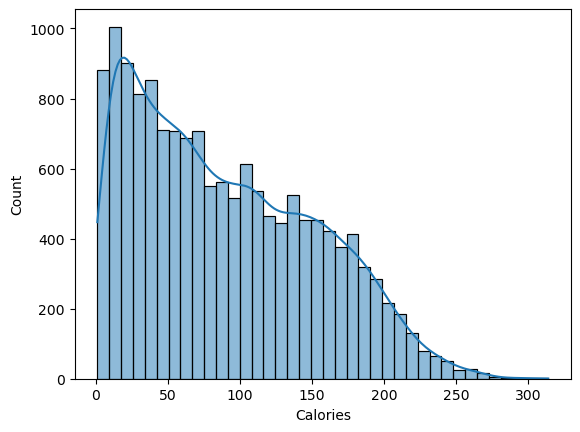

In [49]:
sns.histplot(df['Calories'],kde=True)

## Standard Scaler -> distance based algorithm 

In [50]:
X = df.drop(columns=['Calories','User_ID'],axis=1)
y = df['Calories']

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42) 

## Hyperparameter Tuning

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [53]:
param_grid = {
    'n_estimators':[100,200,300],
    'max_depth':[2,5,10], 
    'min_samples_split':[2,5,10], 
    'min_samples_leaf':[1,2,4]
}

In [54]:
randomized = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_estimators=300),
    param_distributions = param_grid,
    n_iter=10,
    cv=5, 
    n_jobs= -1 ,
    verbose=1 
) 


In [55]:
randomized.fit(X_train,y_train) 

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,RandomForestR...stimators=300)
,param_distributions,"{'max_depth': [2, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [56]:
randomized.best_score_

np.float64(0.9963140766313305)

In [57]:
# Building Random Forest model

RF_model= RandomForestRegressor(max_depth= 10 , n_estimators=300)
RF_model.fit(X_train , y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = RF_model.predict(X_test)
print(y_pred)

[169.54462776 193.3395073   52.66429394 ...  14.8897379  165.71050995
  72.28314818]


In [59]:
from sklearn.metrics import r2_score , mean_absolute_error

In [61]:
r2=  r2_score(y_test , y_pred)* 100
print(r2)

99.6706582660187


In [65]:
mean_absolute_error(y_test , y_pred)

2.3913205918792584